(p1-lab-end2end-ml-project)=
# P1 실습: 머신러닝 프로젝트

**감사의 글**

오렐리앙 제롱<font size='2'>Aurélien Géron</font>의 [Hands-On Machine Learning with Scikit-Learn and PyTorch (O'Reilly, 2025)](https://github.com/ageron/handson-mlp)에 사용된 코드를 참고한 실습 노트북이다. 보다 심화된 이해를 위해 책 원본을 읽을 것을 강력하게 권장한다. 자료를 공개한 오렐리앙 제롱과 일부 그림 자료를 제공해 준 한빛아카데미에게 진심어린 감사를 전한다.

**환경설정**

In [1]:
import sys
import sklearn
from packaging.version import Version

# 파이썬 버전과 scikit-learn 버전 확인
assert sys.version_info >= (3, 10)
assert Version(sklearn.__version__) >= Version("1.6.1")

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 그래프 스타일 설정
plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## 머신러닝 프로젝트와 데이터 분석

### 문제 정의와 데이터

#### 데이터 기초 정보

1990년도에 시행된 미국 캘리포니아 주의 20,640개 구역별 주택 가격 데이터는
경도, 위도, 주택 건물 중위연령, 총 방 수, 총 침실 수, 인구, 가구 수, 중위소득, 중위 주택가격, 해안 근접도
등 총 10개의 **특성**<font size='2'>feature</font>을 포함한다. 

#### 머신러닝 훈련 모델 선택 기준

중위 주택가격을 타깃으로 하는 지도학습 회귀 문제다.

#### 데이터 구하기

캘리포니아 주택 가격 데이터는 매우 유명하여 많은 공개 저장소에서 다운로드할 수 있다.
여기서는 개인 깃허브 리포지토리에 csv 파일을 다운로드해서 사용한다.
`housing_full` 변수는 캘리포니아 주택 가격 데이터를 담고 있는 데이터프레임을 가리킨다.

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/codingalzi/code-workout-ml/master/datasets/housing/housing.csv"
housing_full = pd.read_csv(url)

### 데이터셋 기초 탐색

데이터 탐색은 훈련을 시작하기 전에 주어진 데이터셋의
다양한 특성을 대략적으로 살펴보는 과정이다.
데이터 시각화는 데이터 탐색을 위한 주요 기법 중의 하나이다.

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


#### 범주형 특성

'해안 근접도'는 5개의 범주로 구분된다.
데이터프레임의 `valule_counts()` 메서드는 사용된 특성값과 각각의 특성값이 사용된 횟수를 확인해준다.

In [5]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

#### 수치형 특성

범주형 특성과는 다르게 수치형 특성은 정수 또는 부동소수점으로 구성된 특성이며, 
평균값, 표준편차, 사분범위 등 수치형 특성들의 정보를 확인할 수 있다.
해안 근접도를 제외한 나머지 특성들 모두 수치형 특성이다.

In [6]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


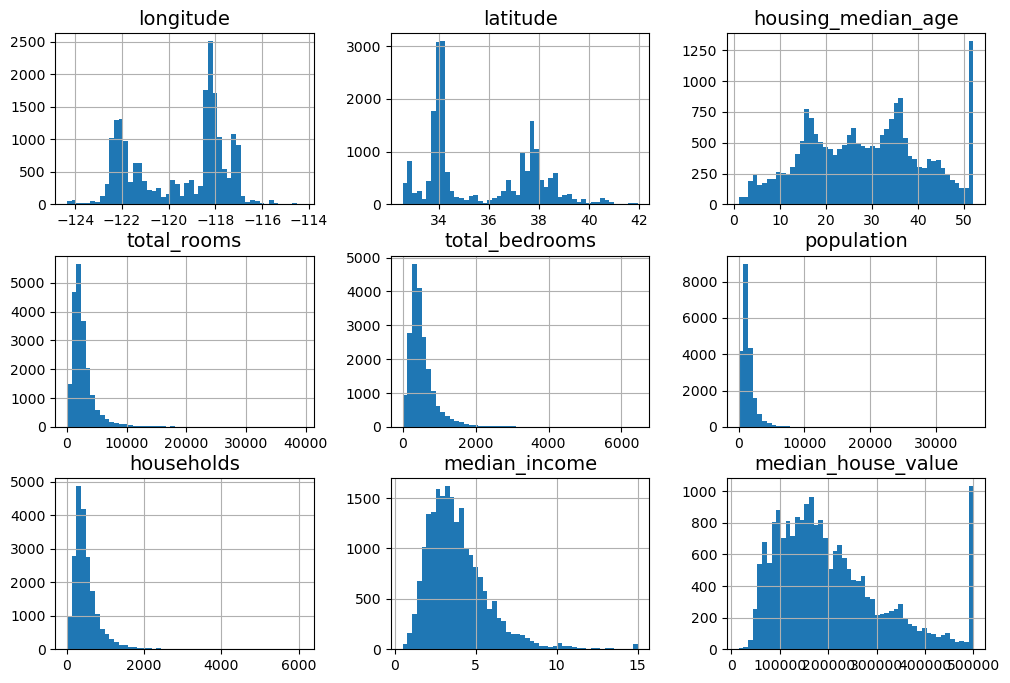

In [7]:
housing_full.hist(bins=50, figsize=(12, 8))

plt.show()

### 훈련셋과 테스트셋

모델 훈련을 시작하기 전에 전체 데이터셋을 보통 **훈련셋**<font size='2'>training set</font>과
**테스트셋**<font size='2'>test set</font>으로 나눈다.

가장 간단한 방법은 전체 데이터에서 무작위로 샘플을 선택하는 **무작위 샘플링**(random sampling)이다.
반면에 **층화 샘플링**(stratified sampling)은 중요한 특성을 기준으로 데이터를 여러 계층으로 나눈 뒤, 전체 데이터에서의 비율이 각 데이터셋에도 비슷하게 유지되도록 샘플을 선택하는 방법이다.


#### 무작위 샘플링

아래 코드는 무작위 샘플링을 이용하여 8대 2로 훈련셋과 테스트셋으로 구분한다.

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

#### 층화 샘플링

먼저 구역별 중위소득 특성을 대상으로 히스토그램을 그려보면
대부분 구역의 중위소득이 1.5 ~ 6.0, 즉 15,000에서 60,000 달러 사이인 것을 알 수 있다.

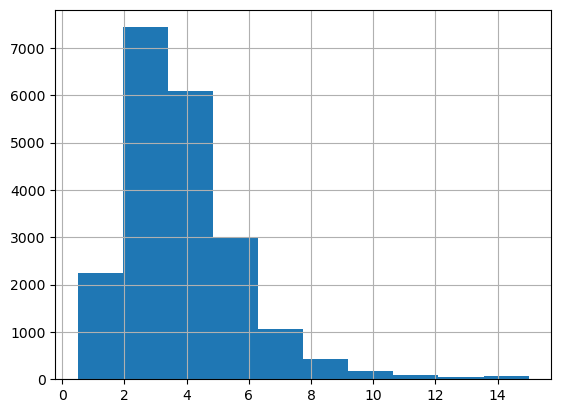

In [9]:
housing_full['median_income'].hist()
plt.show()

따라서 중위소득 구간을 아래처럼 5개로 구분한 다음에 층화 샘플링을 이용하여
훈련셋과 테스트셋을 구분하면 좋을 것 같아 보인다.

In [10]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                                    labels=[1, 2, 3, 4, 5])

먼저 언급된 5 개의 구간으로 구분하는 `"income_cat"` 특성을 추가한다.
`pd.cut()` 함수는 특성과 구간 구분이 주어지면 각 구간에 해당하는 특성값들에 지정된 레이블을 할당하는
형식으로 새로운 특성값들을 만들어 낸다.

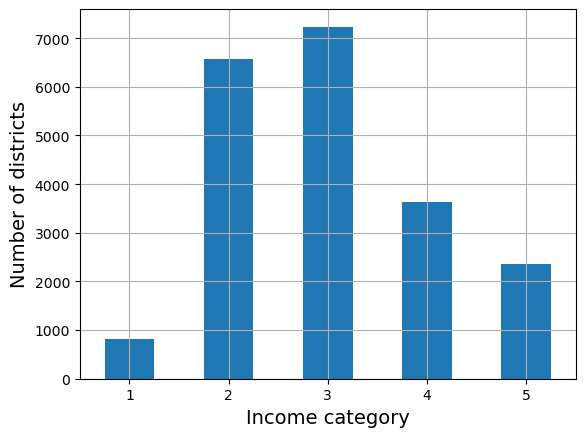

In [11]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()

이제 `"income_cat"` 특성에 사용된 값들의 분포 비율을 반영하면서 
훈련셋과 테스트셋을 8대 2로 나눈다.
사이킷런의 `train_test_split()` 함수는 데이터프레임에 속한 샘플을
지정된 비율로 두 개의 데이터프레임으로 나눌 때
층화 샘플링을 지원한다.

In [12]:
strat_train_set, strat_test_set = train_test_split(
    housing_full, 
    test_size=0.2,
    stratify=housing_full["income_cat"],            # 층화 샘플링을 위한 기준이 되는 열 지정
    random_state=42)

**`income_cat` 특성 삭제**

해당 특성은 층화 샘플링을 위한 용도로만 사용되기에 더 이상 필요 없어서 
훈련셋과 테스트셋 모두에서 삭제한다.

In [13]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### 훈련셋 대상 EDA

데이터 탐색(EDA)은 훈련셋만을 대상으로 진행한다.
이유는 머신러닝 모델에 사용될 좋은 훈련셋으로 활용하는 방안을 모색하기 위해서인데,
테스트셋을 사용하면 미래에 발생할 데이터를 안다고 가정하는 결과를 초래하기 때문이다.

훈련셋은 캘리포니아 전체 데이터셋에서 앞서 층화 샘플링을 이용하여 얻어진 데이터셋으로 지정한다

In [14]:
housing_train = strat_train_set.copy()

훈련셋의 크기는 전체 데이터셋의 크기인 20,640의 80%인 16,512다.

In [15]:
housing_train.shape

(16512, 10)

#### 상관관계

특성들 사이의 선형 상관관계를 피어슨 상관계수로 계산한다.
단, 수치형 특성만 대상으로 한다.

In [16]:
corr_matrix = housing_train.corr(numeric_only=True)

Seaborn 라이브러리의 히트맵 함수를 이용하여 상관관계의 강도를 시각화해본다.

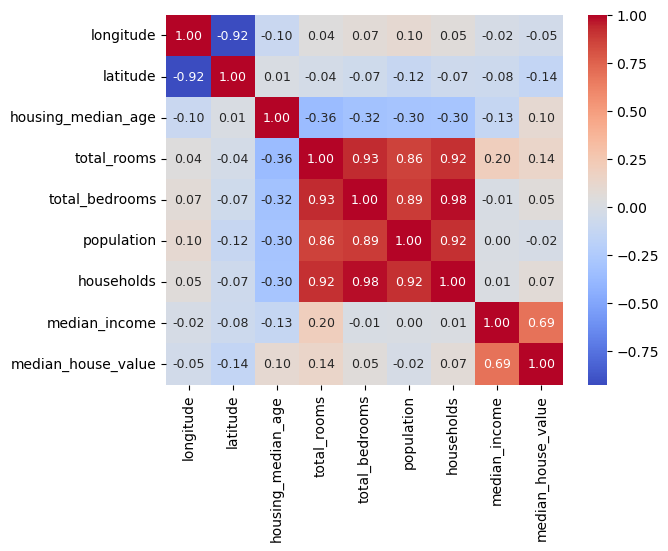

In [17]:
import seaborn as sns
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            annot_kws={"size": 9})
plt.show()

중위 주택가격과 중위소득의 상관계수가 0.68로 상당히 높다.

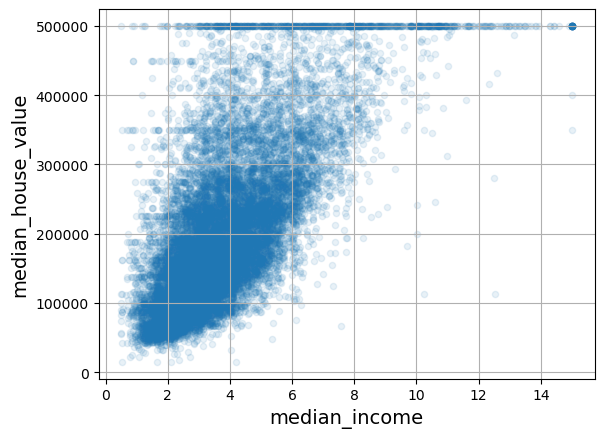

In [18]:
housing_train.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)

plt.show()

## 데이터 준비에서 모델 평가까지

### 입력 데이터와 타깃

지도학습 방식으로 중위 주택가격을 예측하는 모델을 훈련시키려면
훈련셋을 타깃셋과 입력 데이터셋으로 분리해야 한다.
입력 데이터셋 또한 일반적으로 훈련셋으로 불린다.

In [19]:
# 훈련셋 (입력 데이터셋)
X_train = housing_train.drop("median_house_value", axis=1)

# 타깃셋
y_train = housing_train["median_house_value"].copy()

### 데이터 정제와 전처리

데이터 탐색을 통해 확인한 지도학습 회귀 모델을 훈련시키기 위해 먼저
적절한 훈련셋(입력 데이터셋)을 준비해야 한다.
적절한 훈련셋(입력 데이터셋) 준비는 데이터 정제와 데이터 전처리 과정으로 이루어진다.

데이터 정제와 전처리 전과정을 사이킷런 라이브러리에서 제공하는 API를 활용한다.
그런 다음 사이킷런 API를 연동하여 정제와 전처리 전 과정을 
한꺼번에 순차적으로 처리하는 파이프라인<font size='2'>pipeline</font>으로 구성하여
자동화는 방식까지 소개한다.

#### 결측치 처리

`'total_bedrooms'` 특성에 결측치(`NaN`)가 일부 포함되어 있다.

**SimpleImputer 변환기**

`SimpleImputer` 변환기를 활용하여 수치형 결측치를 해당 특성의 중앙값<font size='2'>median</font>으로 대체한다.
아래 코드는 결측치를 해당 특성의 중앙값으로 대체하는 기능을 갖는
`SimpleImputer` 변환기 객체를 `imputer`에 할당한다.

In [20]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

참고로 `SimpleImputer`의 객체를 생성할 때 사용할 수 있는 `strategy`는 다음과 같다.

- `"mean"`: 평균값으로 채움 (수치형 데이터 전용) - 기본값
- `"median"`: 중간값(중앙값)으로 채움 (수치형 데이터 전용)
- `"most_frequent"`: 최빈값(가장 자주 등장하는 값)으로 채움 (수치형/문자열 데이터 모두 가능)
- `"constant"`: 지정한 상수로 채움. 
    `strategy` 매갭변수에 대한 키워드 인자 이외에 `fill_value` 매개변수의 키워드 인자로 지정

    ```python
    SimpleImputer(strategy="constant", fill_value="채울값")
    ```

#### 원-핫 인코딩

사이킷런의 `OneHotEncoder` 변환기가 원-핫 인코딩을 지원한다.

In [21]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

원-핫 인코딩 과정에서 새로 생성되는 특성들을 이름은 다음과 같으며,
**더미 특성**<font size='2'>dummy features</font>으로 불린다.

새롭게 생성된 5개의 특성은 기존에 주어진 특성 대신 사용되는 특성이라는 의미에서 더미 특성으로 불린다.
여기서는 해안 근접도 특성에 사용된 실제 값을 대변하는 특성으로 사용된다.

#### 특성 스케일링

**min-max 스케일링**

min-max 스케일링은 정규화의 한 방식이다.
아래 식을 이용하여 특성값 $x$를 0에서 1 사이의 값으로 변환한다.
$max$ 와 $min$ 은 각각 해당 특성값들의 최댓값과 최솟값을 가리킨다.

$$
\frac{x-min}{max-min}
$$

min-max 스케일링은 이상치에 매우 민감하다.
예를 들어 이상치가 매우 크면 분모가 분자에 비해 훨씬 크게 되어 변환된 값이 0 근처에 몰리게 된다.
사이킷런의 `MinMaxScaler` 변환기가 min-max 스케일링을 지원한다.

In [22]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))

**표준화**

표준화<font size='2'>standardization</font>는 아래식을 이용하여 특성값 $x$를 변환한다.
단, $\mu$ 와 $\sigma$ 는 각각 해당 특성값들의 평균값과 표준편차를 가리킨다.

$$
\frac{x-\mu}{\sigma}
$$

표준화 스케일링으로 변환된 특성은 
평균값은 0, 표준편차는 1인 분포를 따르며, 이상치에 상대적으로 덜 영향을 받는다.
사이킷런의 `StandardScaler` 변환기가 표준화 스케일링을 지원한다.

In [23]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

#### 특성 변환

**`FunctionTransformer` 변환기**

로그 변환처럼 미리 어떤 정보를 확인할 필요 없이 바로 데이터 변환을 진행할 수 있는 
경우 `FunctionTransformer` 변환기를 활용한다.

In [24]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log)

아래 그림은 구역별 인구로 구성된 `population` 특성값에 로그함수를 적용할 때 분포가 보다 균형잡히는 것을 잘 보여준다.

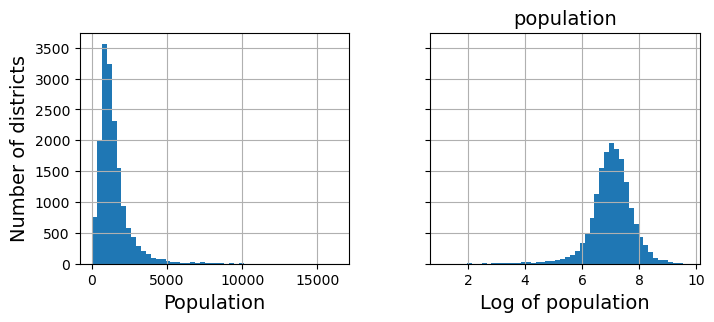

In [25]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)

X_train["population"].hist(ax=axs[0], bins=50)

log_pop = log_transformer.transform(X_train[["population"]])
log_pop.hist(ax=axs[1], bins=50)

axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")

plt.show()

### 사이킷런 모델, 변환기, 파이프라인

데이터 정제와 전처리의 모든 단계가 정확한 순서대로 진행되어야 한다.
사이킷런은 여러 변환기를 순차적으로 또는 병렬적으로 실행하는
파이프라인 기능을 지원한다.

#### `Pipeline` 클래스

**수치형 특성 변환 기본 파이프라인**

In [26]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])

#### `make_pipeline()` 함수

`make_pipeline()` 함수를 이용하여 변환기의 이름을
직접 지정하지 않으면서 파이프라인을 생성할 수도 있다.

In [27]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

#### `ColumnTransformer` 클래스

특성별로 파이프라인을 지정할 수 있다.

- 수치형 대 범주형 특성 구분

In [28]:
from sklearn.compose import ColumnTransformer

# 수치형 특성 리스트 지정
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
# 범주형 특성 리스트 지정
cat_attribs = ["ocean_proximity"]

- 범주형 특성 변환 파이프라인

In [29]:
# 범주형 특성 변환 파이프라인
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

- 전체 특성 변환 파이프라인

In [30]:
# 전체 특성 변환기
num_cat_preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

#### 종합: 캘리포니아 데이터셋 변환 파이프라인

`ColumnTransformer` 클래스와 `Pipeline` 클래스를 이용하여
캘리포니아 주택 가격 데이터의 입력 데이터셋을 한꺼번에 변환하는 
파이프라인 변환기를 아래 코드에서 정의된 네 개의 파이프라인을 이용하여 구현한다.

In [31]:
# 파이프라인 1: 여러 수치형 특성에 로그 변환을 적용하는 사용자 정의 변환기
log_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    StandardScaler())

# 파이프라인 2: 기타 특성에 적용될 기본 수치형 특성 변환기
default_num_pipeline = make_pipeline(SimpleImputer(strategy="median"),
                                     StandardScaler())

앞서 언급된 모든 변환기를 특성별로 적용하는 변환기를
`ColumnTransformer` 클래스를 이용하여 정의한다.

`remainder=default_num_pipeline`는
그때까지 언급되지 않은 나머지 특성들을 처리하는 변환기를
키워드 인자로 지정한다.

In [32]:
from sklearn.compose import make_column_selector

preprocessing = ColumnTransformer([
        ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population",
                               "households", "median_income"]),
        ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
        ],
        remainder=default_num_pipeline # 남은 특성 하나: housing_median_age
        )

모든 파이프라인 변환기의 사용법은 동일하다.
아래 코드는 훈련셋을 특성별로 지정된 변환을 실행한다.
반환값이 넘파이 어레이임에 주의한다.

In [33]:
X_train_arr = preprocessing.fit_transform(X_train)

특성이 총 13개로 늘었으며,
특성별 이름은 변환기의 `get_feature_names_out()` 메서드로 확인한다.

- 해안 근접도 더미 특성: 5개로 변환. 기존 해안 근접도 특성 제거 후 5개 더미 특성 추가.

In [34]:
X_train_arr.shape

(16512, 13)

In [35]:
preprocessing.get_feature_names_out()

array(['log__total_bedrooms', 'log__total_rooms', 'log__population',
       'log__households', 'log__median_income',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__longitude',
       'remainder__latitude', 'remainder__housing_median_age'],
      dtype=object)

In [36]:
X_train_df = pd.DataFrame(X_train_arr,
                          columns=preprocessing.get_feature_names_out(),
                          index=X_train.index)
X_train_df.head()

,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__longitude,remainder__latitude,remainder__housing_median_age
13096,1.324114,0.637892,0.456906,1.310369,-1.071522,0.0,0.0,0.0,1.0,0.0,-1.423037,1.013606,1.861119
14973,-0.252671,-0.063576,-0.711654,-0.142030,1.194712,1.0,0.0,0.0,0.0,0.0,0.596394,-0.702103,0.907630
3785,-0.925266,-0.859927,-0.941997,-0.913030,-0.756981,0.0,1.0,0.0,0.0,0.0,-1.203098,1.276119,0.351428
14689,0.952773,0.943475,0.670700,0.925373,-0.912253,0.0,1.0,0.0,0.0,0.0,1.231216,-0.884924,-0.919891
20507,1.437622,1.003590,0.719093,1.481464,0.034537,0.0,0.0,0.0,0.0,1.0,0.711362,-0.875549,0.589800


In [37]:
X_train_df.info()

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   log__total_bedrooms              16512 non-null  float64
 1   log__total_rooms                 16512 non-null  float64
 2   log__population                  16512 non-null  float64
 3   log__households                  16512 non-null  float64
 4   log__median_income               16512 non-null  float64
 5   cat__ocean_proximity_<1H OCEAN   16512 non-null  float64
 6   cat__ocean_proximity_INLAND      16512 non-null  float64
 7   cat__ocean_proximity_ISLAND      16512 non-null  float64
 8   cat__ocean_proximity_NEAR BAY    16512 non-null  float64
 9   cat__ocean_proximity_NEAR OCEAN  16512 non-null  float64
 10  remainder__longitude             16512 non-null  float64
 11  remainder__latitude              16512 non-null  float64
 12  remainder__housing_median_age 

### 모델 선택, 훈련, 평가

#### 다양한 모델 활용

전처리된 입력 데이터셋을 이용하여 여러 회귀 모델을 같은 조건에서 훈련시켜 서로 비교해서 최선의 모델을 선택할 수 있다.

**선형회귀 모델 활용**

- 훈련

In [38]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train_df, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- 선형회귀 모델의 훈련셋에 대한 RMSE: 예측값의 RMSE가 매우 높게 나온다. 모델 훈련이 제대로 진행되지 못한 과소 적합이 발생하였으며 이는 선형회귀 모델이 적절하지 않음을 의미한다.

In [39]:
from sklearn.metrics import root_mean_squared_error

housing_predictions_lin = lin_reg.predict(X_train_df)
lin_rmse = root_mean_squared_error(y_train, housing_predictions_lin)
lin_rmse

71384.69747107037

**결정트리 회귀 모델 활용**

- 훈련

In [40]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_df, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

- 결정트리 회귀 모델의 훈련셋에 대한 RMSE: RMSE가 0으로 나온다. 이는 결정트리 모델이 심하게 과대 적합되었음을 의미한다. 이런 모델은 전혀 의미가 없다.

In [41]:
housing_predictions_tree = tree_reg.predict(X_train_df)
tree_rmse = root_mean_squared_error(y_train, housing_predictions_tree)
tree_rmse

0.0

**랜덤 포레스트 회귀 모델**

- 훈련

In [42]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train_df, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

- 랜덤 포레스트 회귀 모델의 훈련셋에 대한 RMSE: RMSE가 결정트리보다는 높지만 선형회귀 모델 보다는 훨씬 낮다.

In [43]:
housing_predictions_forest = forest_reg.predict(X_train_df)
forest_rmse = root_mean_squared_error(y_train, housing_predictions_forest)
forest_rmse

18085.877602230124

#### 교차 검증으로 모델 비교

**사이킷런의 `cross_val_score()` 함수**

`cross_val_score()` 함수는 지정된 모델을 k-겹 교차 검증을 활용하여 훈련과 평가를 동시에 진행한다.
교차검증은 다만 모델 평가용도로만 폴드를 구분하여 훈련할 뿐 훈련된 모델 객체 자체를 반환하지는 않는다.
예를 들어 아래 코드는 결정트리 모델에 대해 교차 검증을 실행한다.

`cross_val_score()` 함수 호출에 사용된 키워드 인자는 다음과 같다.

- `scoring="neg_mean_squared_error"` 옵션
    - 훈련중인 모델의 성능을 측정하는 **효용함수** 지정
    - 모델의 성능 측정값은 높을 수록 좋은 성능으로 평가되기에 회귀 모델의 경우 일반적으로 RMSE의 음숫값을 사용함.
- `cv=5`: 5-겹 교차 검증 진행

`cross_val_score()` 함수의 반환값은 `scoring="neg_mean_squared_error"` 옵션으로 인해 음수값이다.
따라서 다시 양수로 만들어서 `tree_rmses` 변수에 할당한다.

**선형회귀 모델에 대한 교차 검증**

In [44]:
from sklearn.model_selection import cross_val_score

lin_rmses = -cross_val_score(lin_reg, X_train_df, y_train,
                              scoring="neg_root_mean_squared_error", cv=5)

`cv=5` 설정에 의해 5개의 폴드를 사용하며 매번 RMSE를 측정한다.

In [45]:
lin_rmses

array([71476.86359218, 70631.97969964, 71686.27309599, 72431.5069909 ,
       71126.32630022])

평균값은 다음과 같다.

In [46]:
lin_rmses.mean()

np.float64(71470.58993578507)

**결정트리 모델에 대한 교차 검증**

In [47]:
tree_rmses = -cross_val_score(tree_reg, X_train_df, y_train,
                              scoring="neg_root_mean_squared_error", cv=5)
tree_rmses.mean()

np.float64(68327.40914929542)

결정트리의 훈련셋에 대한 RMSE가 0으로 완벽해 보였지만 교차검증 결과는 선형회귀 모델과 수준이 비슷하다.

**랜덤 포레스트 모델에 대한 교차 검증**

램덤 포레스트 모델에 교차 검증을 적용하면 보다 많은 시간이 걸린다 (몇 분 정도).
그만큼 랜덤 포레스트 모델이 보다 복잡한 훈련을 진행하기 때문이다.
하지만 결과적으로 랜덤 포레스트 회귀 모델의 성능이 보다 좋다.

In [48]:
forest_rmses = -cross_val_score(forest_reg, X_train_df, y_train,
                                scoring="neg_root_mean_squared_error", cv=5)

forest_rmses.mean()

np.float64(49395.74704790256)

선형회귀와 결정트리 모델에 비하면 많이 낮지만 훈련셋에 대한 RMSE에 비하면 매우 높아졌다.
따라서 랜덤 포레스트 모델 또한 훈련셋에 너무 특화되어 있다, 즉 과대적합이 발생하였다.

### 모델 하이퍼파라미터 미세 조정

#### 그리드 탐색

그리드 탐색에 사용될 모델을 전처리와 함께 지정한다.
파이프라인에 포함된 전처리와 예측기에 사용되는 하이퍼파라미터 중에서 미세조정에 사용될 하이퍼파라미터가 가질 수 있는 값들의 리스트를 지정한다.

랜덤 포레스트 모델의 `n_estimators`(트리 개수)와 `max_features`(분할에 사용할 최대 특성 수)
두 하이퍼파라미터를 대상으로 총 15개의 조합에 대해 모델을 지정한 다음에
매번 3-겹 교차 검증을 실행하기에
아래 코드는 총 45번 훈련을 진행한다.

```
(3 * 3 + 2 * 3) * 3 = 45
```

아래 코드를 실행하면 컴퓨터 사양에 따라 몇 분 이상 걸릴 수 있다.

In [49]:
from sklearn.model_selection import GridSearchCV

# 랜덤 포레스트 기본 모델
forest_reg_base = RandomForestRegressor(random_state=42)

# 하이퍼파라미터 조합: 3*3 + 2*3 조합 확인
# 랜덤 포레스트 모델의 트리 개수(n_estimators)와 최대 특성 수(max_features) 대상 지정
param_grid = [
    {'n_estimators': [50, 100, 150],   # 트리 개수
     'max_features': [4, 6, 8]},       # 최대 특성 수
    {'n_estimators': [100, 200],
     'max_features': [8, 10, 12]},
]

# 그리드 탐색 객체 생성: 전체 파이프라인과 하이퍼파라미터 그리드, 교차 검증 분할 수, 평가 지표 지정
grid_search = GridSearchCV(forest_reg_base, 
                           param_grid, 
                           cv=3,
                           scoring='neg_root_mean_squared_error')

# 그리드 탐색 수행
grid_search.fit(X_train_df, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_features': [4, 6, ...], 'n_estimators': [50, 100, ...]}, {'max_features': [8, 10, ...], 'n_estimators': [100, 200]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

**그리드 탐색 결과**

그리드 탐색을 통해 찾아낸 최적의 하이퍼파라미터 조합은 다음과 같다.

In [50]:
grid_search.best_params_

{'max_features': 6, 'n_estimators': 150}

그리드 탐색을 통해 찾아낸 최적의 모델은 다음과 같다.

In [51]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",6
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

최적 모델의 교차검증 RMSE는 다음과 같다.
`best_score_` 값이 음수이기에 양수로 만들어야 함에 주의한다.

In [52]:
-grid_search.best_score_

np.float64(49222.78493657411)

#### 랜덤 탐색

그리드 탐색은 적은 수의 하이퍼파라미터 조합을 실험해볼 때만 유용하다.
반면에 하이퍼파라미터 탐색 공간이 커서 조합 경우의 수가 많아지면 훈련 시간이 너무
올래 걸려 활용하기 어렵다.
이런 경우 랜덤 탐색이 보다 효율적으로 최적의 하이퍼파라미터 조합을 찾아낼 수 있다.

아래 코드는 무작위로 선택한 10개의 하이퍼파라미터 조합에 대해 3-겹 교차 검증을 진행하기에 총 30(=10x3)번 훈련을 진행한다.
아래 코드는 컴퓨터 사양에 따라 몇 분 이상 걸릴 수 있다.

**무작위 추출 표본분포 함수 선택**

랜덤 탐색을 진행하려면
지정된 하이퍼파라미터에 대한 값을 무작위로 지정하는 데에 사용되는
표본분포 함수를 지정해야 한다.
아래 랜덤 탐색에서는 이산 균등 분포를 사용하는 `randint()` 함수를 이용한다.

```python
'n_estimators': randint(low=50, high=300)
'max_features': randint(low=2, high=20)
```

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 랜덤 탐색을 위한 하이퍼파라미터 분포 지정:
# - 트리 개수는 50~300 범위에서 균등 분포로 샘플링
# - 최대 특성 수는 2~20 범위에서 균등 분포로 샘플링
param_distribs = {'n_estimators': randint(low=50, high=300),
                  'max_features': randint(low=2, high=20)}

# 랜덤 탐색 객체 생성: 전체 파이프라인과 하이퍼파라미터 분포, 교차 검증 분할 수, 평가 지표 지정
rnd_search = RandomizedSearchCV(forest_reg_base,
                                param_distributions=param_distribs, 
                                n_iter=10, 
                                cv=3,
                                scoring='neg_root_mean_squared_error', 
                                random_state=42)

# 랜덤 탐색 수행
rnd_search.fit(X_train_df, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_features': <scipy.stats....0017F3DAC1E50>, 'n_estimators': <scipy.stats....0017F3D7F8D70>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versioncha

랜덤 탐색 과정에서 훈련된 10개 모델 각각의 하이퍼파라미터와
최고 성능 모델 등의 정보는 그리드 탐색 객체와 동일한 속성에 저장된다.

In [54]:
rnd_search.best_params_

{'max_features': 7, 'n_estimators': 179}

In [55]:
rnd_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",179
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [56]:
-rnd_search.best_score_

np.float64(49205.46270734026)

### 최적 모델 활용과 평가

랜덤 탐색으로 확인된 최적 모델의 교차검증 RMSE가 조금 더 낮기에
해당 모델을 최종 모델로 지정한다.

In [57]:
final_model = rnd_search.best_estimator_